In [1]:
import os, sys

campaign = '3570'

SOFTWARE_DIR = './miniconda3/envs/py312/.local/bin/spine' # Change this path to your software install
DATA_DIR = '/silver/DUNE/data/spine/campaign_'+campaign+'/' # Change this path if you are not on SDF (see main README)
CKOV_DIR = '/silver/DUNE/data/spine/pdvd_beam_'+campaign+'_testbeam_spinelist_0-no_primcut.txt'

# Set software directory
sys.path.insert(0, SOFTWARE_DIR)

In [2]:
import yaml

# Load anatools config file
# Replace the source file with the correct path
DATA_PATH = DATA_DIR + '*.h5'
#DATA_PATH = DATA_DIR + "np02vd_raw_run039305_0106_df-s02-d0_dw_0_20250904T190413_reco_stage1_20260427T211454_offline_reco_stage2_20260428T100454_offline_larcv_spine.h5"
#DATA_PATH = DATA_DIR + "np02vd_raw_run039305_001[0-9]*.h5"

cfg = '../template.yaml'
cfg = yaml.safe_load(open(cfg, 'r').read().replace('DATA_PATH', DATA_PATH))

In [3]:
# Initialize Anatools manager
from spine.driver import Driver

driver = Driver(cfg)


 ██████████   ██████████    ███   ███       ██   ███████████
███        █  ██       ███   █    █████     ██   ██         
  ████████    ██       ███  ███   ██  ████  ██   ██████████ 
█        ███  ██████████     █    ██     █████   ██         
 ██████████   ██            ███   ██       ███   ███████████

Release version: 0.12.3

$CUDA_VISIBLE_DEVICES=None

Configuration processed at: Linux dune2-ijclab-in2p3-fr.lal.in2p3.fr 5.14.0-687.5.3.el9_8.x86_64 #1 SMP PREEMPT_DYNAMIC Tue May 19 14:53:22 EDT 2026 x86_64 x86_64 x86_64 GNU/Linux

base: {world_size: 0, seed: 1781880424}
io:
  reader: {name: hdf5, file_keys: /silver/DUNE/data/spine/campaign_3570/*.h5}
geo: {detector: protodune-vd}
build: {mode: reco, units: cm, fragments: false, particles: true, interactions: true}

Will load 1000 file(s):
 - /silver/DUNE/data/spine/campaign_3570/np02vd_raw_run039324_0000_df-s02-d2_dw_0_20250905T143855_reco_stage1_20260429T173529_offline_reco_stage2_20260429T174912_offline_larcv_spine.h5
 - /silver/

In [4]:

from utils import *
import numpy as np

In [5]:
"""Load beam instrumentation information"""

with open(CKOV_DIR, encoding='utf-8') as file:
    lines = file.readlines()

def read_line(l):
    split = l.split()
    return {'Event': int(split[0]),
     'TOF' : float(split[1]),
     'CKov0': int(split[2]),
     'CKov1': int(split[3]),
     'Momentum': float(split[4])}

beam_instrumentation = [None for i in range(len(lines))]

for i,l in enumerate(lines):
    instr = read_line(l)
    beam_instrumentation[i] = instr

#sort by event id for faster search
beam_instrumentation = sorted(beam_instrumentation,key = lambda instr : instr['Event'])

In [6]:
#function that processes a single data set
def process_iteration(i):
    if i >= len(driver):
        return None
    try:
        data = driver.process(entry=i)
    except:
        return [],[],-1

    #first selection using beam instrumentation info
    instr = event_info(data['run_info'].event,beam_instrumentation)
    if instr == None:
        return [],[],-1
    
    if instr['TOF'] == 0 or (instr['CKov0']==0 and instr['CKov1']==1):
        return [],[],-1
    
        
    data_reco_particles =  np.array(data['reco_particles'])
    data_reco_interactions=  np.array(data['reco_interactions'])

    #select beam primary particles
    primary_particles = get_primaries(data_reco_particles)
    aligned_primary_particles = get_particles_aligned_with_beam(primary_particles,0.9)
    opposed_primary_particles = get_particles_opposed_to_beam(primary_particles,-0.9)
    direction_aligned_primary_particles = np.concatenate([aligned_primary_particles,opposed_primary_particles])
    beam_primary_particles = get_particles_close_to_beam(direction_aligned_primary_particles,25,70)

    #select all particles in a beam primary interaction
    beam_particles_mask = np.zeros(len(data_reco_particles),dtype = bool)
    beam_interactions_mask = np.zeros(len(data_reco_interactions),dtype = bool)
    beam_primary_index = 0
    beam_primary_count = len(beam_primary_particles)

    particle_index = 0
    interaction_index = 0
    
    for i in data_reco_interactions:
        for p in i.particles:
            if beam_primary_index == beam_primary_count:
                break
            if p.id == beam_primary_particles[beam_primary_index].id: #if the interaction contains a beam particles, mark this interaction 
                beam_interactions_mask[i.id] = True
                beam_primary_index += 1 #move to the next beam primary particle
                
        if beam_interactions_mask[i.id] == True: #if this interaction was marked, mark all its particles and reindex ids
            i.id = interaction_index
            interaction_index += 1
            for p in i.particles:
                beam_particles_mask[p.id] = True
                p.id = particle_index
                particle_index += 1
            

        
    return data_reco_particles[beam_particles_mask],data_reco_interactions[beam_interactions_mask],data['run_info'].event

In [7]:
"""Process a lot of data, parallel"""
from multiprocessing import Pool
from tqdm import tqdm

N_data_sets = len(driver)

reco_particles = []
reco_interactions = [] 
interaction_event = [] #contains at position i the id of the event of the iteraction with id i


#launch in parallel over all data sets
with Pool() as pool:  
    try:
        results = list(tqdm(
        pool.imap(process_iteration, range(N_data_sets)),
        total=N_data_sets
    ))
        pool.close()
        pool.join()   
    except Exception as e:
        pool.terminate() 
        pool.join()
        raise


results_particles,results_interactions,events =  zip(*results)
index_p = 0
index_i = 0

#aggregate the results and reindex the particles id
for i,interactions in enumerate(results_interactions):
    reco_interactions.extend(interactions)
    interaction_event.extend([events[i] for j in range(len(interactions))])
    for inter in interactions:
        inter.id += index_i
        for p in inter.particles:
            p.interaction_id = inter.id
    index_i += len(interactions)


for i,particles in enumerate(results_particles):
    for p in particles:
        p.id += index_p
    reco_particles.extend(particles)
    index_p += len(particles)



reco_particles = np.array(reco_particles)
reco_interactions = np.array(reco_interactions)
interaction_event = np.array(interaction_event)

100%|█████████████████████████████████████| 22969/22969 [04:18<00:00, 88.75it/s]


In [8]:
"""Store the data in a file, full RecoParticle object"""
import pickle

with open("data/data_1GeV_beam_particles_new.pkl", "wb") as f:
    pickle.dump(reco_particles, f)
with open("data/data_1GeV_beam_interactions_new.pkl", "wb") as f:
    pickle.dump(reco_interactions, f)
with open("data/1GeV_beam_interaction_event.pkl", "wb") as f:
    pickle.dump(interaction_event, f)
with open("data/1GeV_beam_instrumentation.pkl", "wb") as f:
    pickle.dump(beam_instrumentation, f)

In [21]:
primary = get_primaries(reco_particles)


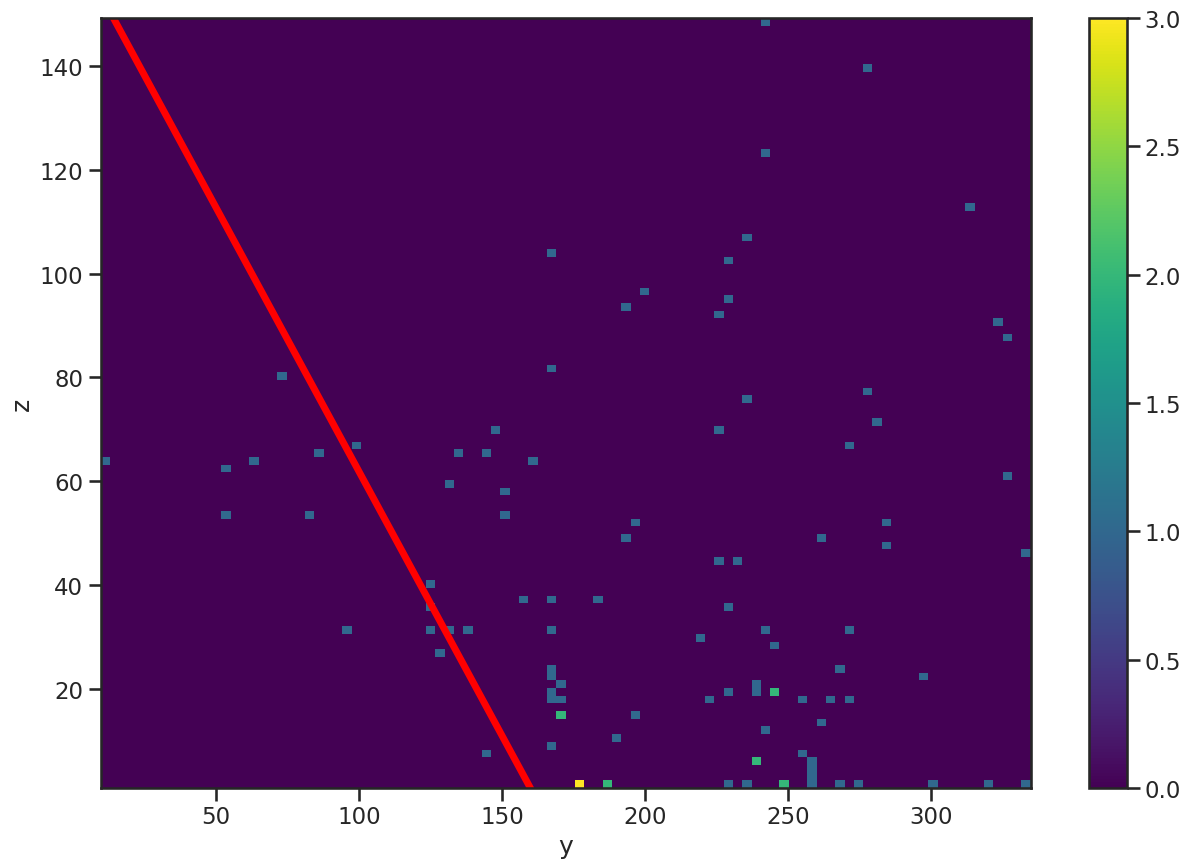

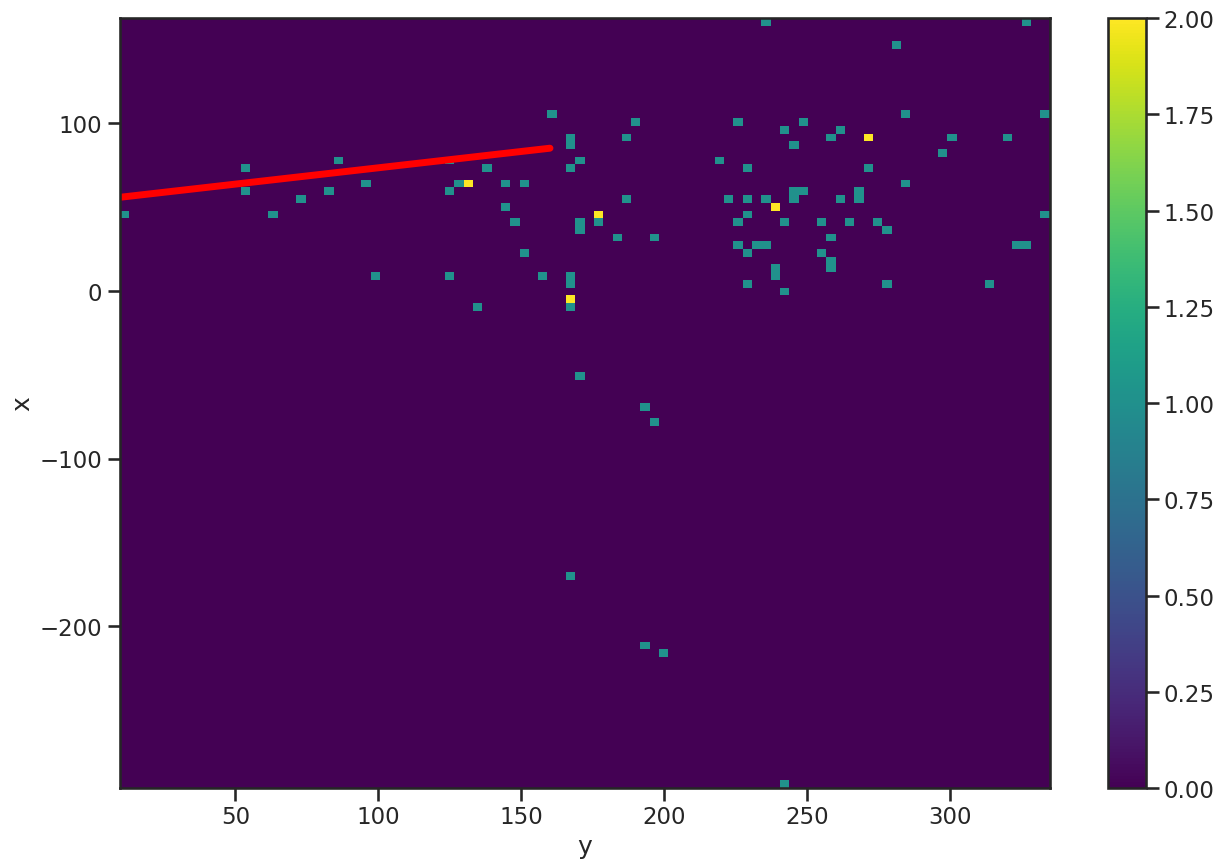

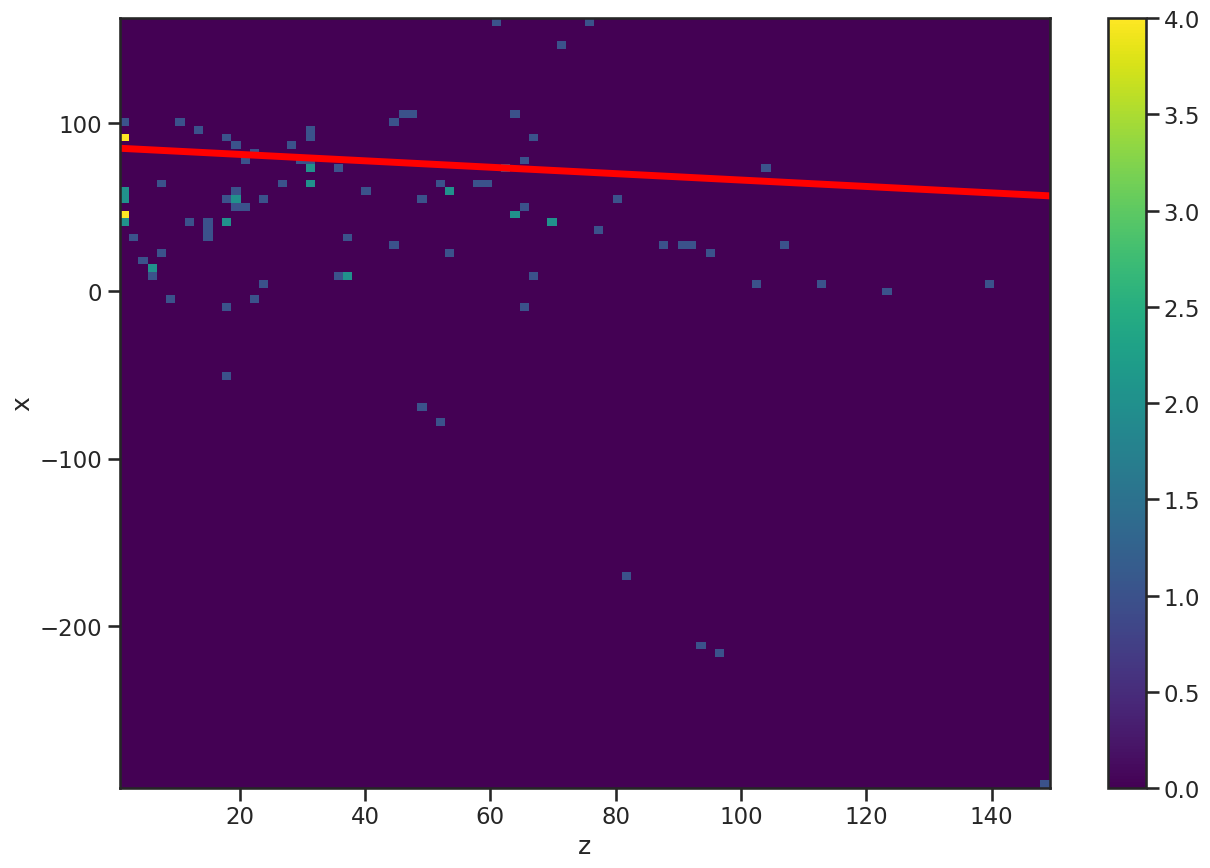

In [22]:
start_pos_histogram(reco_particles,[100,100],[100,100],[100,100],True)

# Cosmics

Avoid using this, files get very big very quickly

In [5]:
#function that processes a single data set
def process_iteration(i):
    if i >= len(driver):
        return None
    try:
        data = driver.process(entry=i)
    except:
        return [],[],-1       
    data_reco_particles =  np.array(data['reco_particles'])
    data_reco_interactions=  np.array(data['reco_interactions'])
    return data_reco_particles,data_reco_interactions,data['run_info'].event

In [6]:
"""Process a lot of data, parallel"""
from multiprocessing import Pool
from tqdm import tqdm

N_data_sets = 5000

reco_particles = []
reco_interactions = [] 
interaction_event = [] #contains at position i the id of the event of the iteraction with id i


#launch in parallel over all data sets
with Pool() as pool:  
    try:
        results = list(tqdm(
        pool.imap(process_iteration, range(N_data_sets)),
        total=N_data_sets
    ))
        pool.close()
        pool.join()   
    except Exception as e:
        pool.terminate() 
        pool.join()
        raise


results_particles,results_interactions,events =  zip(*results)
index_p = 0
index_i = 0

#aggregate the results and reindex the particles id
for i,interactions in enumerate(results_interactions):
    reco_interactions.extend(interactions)
    interaction_event.extend([events[i] for j in range(len(interactions))])
    for inter in interactions:
        inter.id += index_i
        for p in inter.particles:
            p.interaction_id = inter.id
    index_i += len(interactions)


for i,particles in enumerate(results_particles):
    for p in particles:
        p.id += index_p
    reco_particles.extend(particles)
    index_p += len(particles)



reco_particles = np.array(reco_particles)
reco_interactions = np.array(reco_interactions)
interaction_event = np.array(interaction_event)

100%|███████████████████████████████████████| 5000/5000 [02:11<00:00, 38.05it/s]


In [8]:
"""Store the data in a file, full RecoParticle object"""
import pickle

with open("../Benjamin_data/data_cosmics_interactions.pkl", "wb") as f:
    pickle.dump(reco_interactions, f)
